In [2]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm.auto import tqdm
import torch
from torch.optim import SGD
from torch.utils.data import TensorDataset, Dataset, DataLoader

In [5]:
from src.graphs import random_k_out_graph
from src.models.MatrixFactorization import MF
from src.training import new_train, new_validate
from src.users import User

ImportError: cannot import name 'new_train' from 'src.training' (/Users/haowen/Documents/Decentral RS/fed-learning-main/src/training/__init__.py)

In [8]:
train_df = pd.read_csv("dataset/ml100k_train.csv")
test_df = pd.read_csv("dataset/ml100k_test.csv")
X_train = train_df[["user_id", "item_id"]]
y_train = train_df["rating"]
X_test = test_df[["user_id", "item_id"]]
y_test = test_df["rating"]
n_users = train_df.user_id.nunique()
n_items = train_df.item_id.nunique()

In [ ]:
UserRandomSamplingDataset(X_train, y_train, batch_size=5)

In [10]:
users = {}
for i in tqdm(range(n_users)):
    model = MF(n_users=n_users, n_items=n_items)
    # model = GeneralizedMFOneLayer(n_users=n_users, n_items=n_items)
    users[i] = User(name=i, model=model, optimizer=SGD(model.parameters(), lr=.01))

  0%|          | 0/943 [00:00<?, ?it/s]

NameError: name 'User' is not defined

In [6]:
graph = random_k_out_graph(n_users, 5, 50)

In [7]:
val_dataset = TensorDataset(
    torch.tensor(X_test.to_numpy(), dtype=int), 
    torch.tensor(y_test.to_numpy(), dtype=float))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)
train_tensor_dataset = TensorDataset(
    torch.tensor(X_train.to_numpy(), dtype=int), 
    torch.tensor(y_train.to_numpy(), dtype=float))
train_tensor_loader = DataLoader(train_tensor_dataset, batch_size=1, shuffle=True)

In [8]:
tbar = tqdm(train_tensor_loader)

  0%|          | 0/75000 [00:00<?, ?it/s]

In [9]:
for idx, (inputs, targets) in enumerate(tbar):
    print(inputs, inputs.shape, inputs.ndim)
    print(targets, targets.shape, targets.ndim)
    break

tensor([[434, 741]]) torch.Size([1, 2]) 2
tensor([4.], dtype=torch.float64) torch.Size([1]) 1


In [10]:
val_losses = new_train(users, train_tensor_loader, val_loader, epochs=5, graph=graph)

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1 Loss: 4.19294 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 75000/75000 [02:03<00:00, 606.58it/s]


Epoch 1
Train Loss: 4.17679649056298
Validation Loss: 2.818232907964404
Time Elapsed: 128.892870 sec


Epoch 2 Loss: 1.75567 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 75000/75000 [01:54<00:00, 654.64it/s]


Epoch 2
Train Loss: 1.75549160106834
Validation Loss: 2.599463320427175
Time Elapsed: 119.808685 sec


Epoch 3 Loss: 1.45663 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 75000/75000 [01:59<00:00, 628.68it/s]


Epoch 3
Train Loss: 1.4570588604456947
Validation Loss: 2.5561869186269854
Time Elapsed: 124.695244 sec


Epoch 4 Loss: 1.34406 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 75000/75000 [01:54<00:00, 653.85it/s]


Epoch 4
Train Loss: 1.3447809626946496
Validation Loss: 2.5558982692340155
Time Elapsed: 119.832752 sec


Epoch 5 Loss: 1.26992 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 75000/75000 [01:58<00:00, 630.37it/s]


Epoch 5
Train Loss: 1.2697501792185546
Validation Loss: 2.5596728884914066
Time Elapsed: 124.249898 sec


In [24]:
preds = np.empty(len(val_loader))
actual = np.empty(len(val_loader))
for idx, (X, y) in enumerate(tqdm(val_loader)):
    if X.ndim == 3:
        X = X.squeeze(0)
        y = y.squeeze(0)
    # print(f"after: {inputs.shape=}")
    # print(f"after: {target.shape=}")
    n_obs = len(y)
    # if len(target) == 1:
    # print(f"{inputs=}")
    # print(f"{target=}")
    user_id = int(X[0, 0])
    score = users[user_id].model(X[:, 0], X[:, 1]).detach().numpy()
    preds[idx] = score.squeeze(0)
    actual[idx] = y.float().detach().numpy().squeeze(0)

  0%|          | 0/24941 [00:00<?, ?it/s]

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

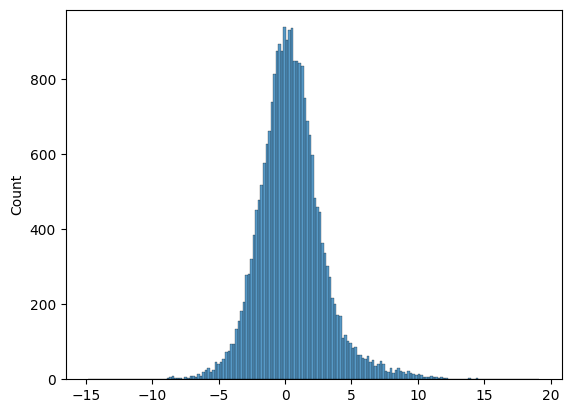

In [28]:
sns.histplot(actual - preds)

In [25]:
np.array(preds) - np.array(actual)

array([-1.27118611,  1.95971417,  1.08242989, ...,  5.19764566,
        0.12789965,  2.92890334])